# 2. Clusterização de Eventos (GMM)

## 2.1 Seleção do Número de Componentes ($K$)

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# Caminho dos relatórios baseado no cenário atual
path = os.path.join("clusters", SCENARIO, METHOD)

if not os.path.exists(path):
    print(f"Erro: Pasta {path} não encontrada.")
else:
    data = []
    
    # Regex para capturar K do nome do arquivo e os valores dentro do TXT
    # Utiliza as variáveis globais METHOD (vwcd), REF_METRIC (full) e THRESHOLD
    file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}_{THRESHOLD}\.txt"    

    for file in os.listdir(path):
        match = re.match(file_pattern, file)
        if match:
            k_val = int(match.group(1))
            full_path = os.path.join(path, file)
            
            with open(full_path, 'r') as f:
                content = f.read()
                
                # Extração via Regex dos valores numéricos
                aic = re.search(r"AIC.*: ([\d\.-]+)", content)
                bic = re.search(r"BIC.*: ([\d\.-]+)", content)
                ll  = re.search(r"Log-Likelihood: ([\d\.-]+)", content)
                events = re.search(r"Total de Eventos: (\d+)", content)
                
                if aic and bic and ll:
                    data.append({
                        'K': k_val,
                        'Log-Likelihood': float(ll.group(1)),
                        'AIC': float(aic.group(1)),
                        'BIC': float(bic.group(1))
                    })

    if not data:
        print("Nenhum relatório encontrado para os parâmetros fornecidos.")
    else:
        # Criar DataFrame e ordenar por K
        df_comp = pd.DataFrame(data).sort_values('K').reset_index(drop=True)
        
        # Calcular a diferença (Delta) entre o K atual e o anterior
        df_comp['Delta_LL']  = df_comp['Log-Likelihood'].diff()
        df_comp['Delta_AIC'] = df_comp['AIC'].diff()
        df_comp['Delta_BIC'] = df_comp['BIC'].diff()

        # Colocar 0 se o Delta for NaN (primeira linha)
        df_comp['Delta_LL'] = df_comp['Delta_LL'].fillna(0)
        df_comp['Delta_AIC'] = df_comp['Delta_AIC'].fillna(0)
        df_comp['Delta_BIC'] = df_comp['Delta_BIC'].fillna(0)

        print(f"\nCOMPARAÇÃO DE MODELOS - CENÁRIO: {SCENARIO}")
        print(f"Métrica: {REF_METRIC} | Threshold: {THRESHOLD}")
        print("=" * 85)
        print(df_comp.to_string(index=False))
        print("=" * 85)


COMPARAÇÃO DE MODELOS - CENÁRIO: NDT
Métrica: rtt_down | Threshold: 0.95
 K  Log-Likelihood    AIC    BIC  Delta_LL  Delta_AIC  Delta_BIC
 2         -338.47 786.94 939.33      0.00       0.00       0.00
 3         -170.91 507.82 737.78    167.56    -279.12    -201.55
 4         -100.93 423.87 731.41     69.98     -83.95      -6.37
 5           34.12 209.76 594.89    135.05    -214.11    -136.52
 6          116.09 101.82 564.52     81.97    -107.94     -30.37
 7          141.01 107.99 648.27     24.92       6.17      83.75
 8          203.66  38.67 656.54     62.65     -69.32       8.27
 9          203.87  94.26 789.71      0.21      55.59     133.17
10          284.01 -10.02 763.00     80.14    -104.28     -26.71


In [15]:
K = 3
# Carregar o CSV do melhor K
csv_path = os.path.join(path, f"clusters_K{K:02d}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv")
df_cluster = pd.read_csv(csv_path)
df_cluster['sync_score'] = (df_cluster['sync_score'] * 5).astype(int)

# 6. Tabela com médias (mantendo a lógica do primeiro código)
feature_cols = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = df_cluster.groupby('cluster').agg(
    count=('cluster', 'size')
).join(df_cluster.groupby('cluster')[feature_cols].mean())

# Printar com 3 casas decimais para facilitar a leitura
cluster_stats = cluster_stats.round(3)

# ordenar as colunas por rtt, tp e pl para facilitar a comparação entre clusters
cols_order = ['count', 'd_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = cluster_stats[cols_order]
print("Estatísticas por Cluster (Melhor K):")
print(cluster_stats)

Estatísticas por Cluster (Melhor K):
         count  d_rtt_down  d_rtt_up  d_tp_down  d_tp_up   d_pl  sync_score
cluster                                                                    
0           79       0.239     0.192      0.040    0.011 -0.003       2.557
1           20       5.521     5.345     -0.606   -0.574  0.009       3.500
2           19      -0.845    -0.844      2.484    1.813 -0.012       3.421


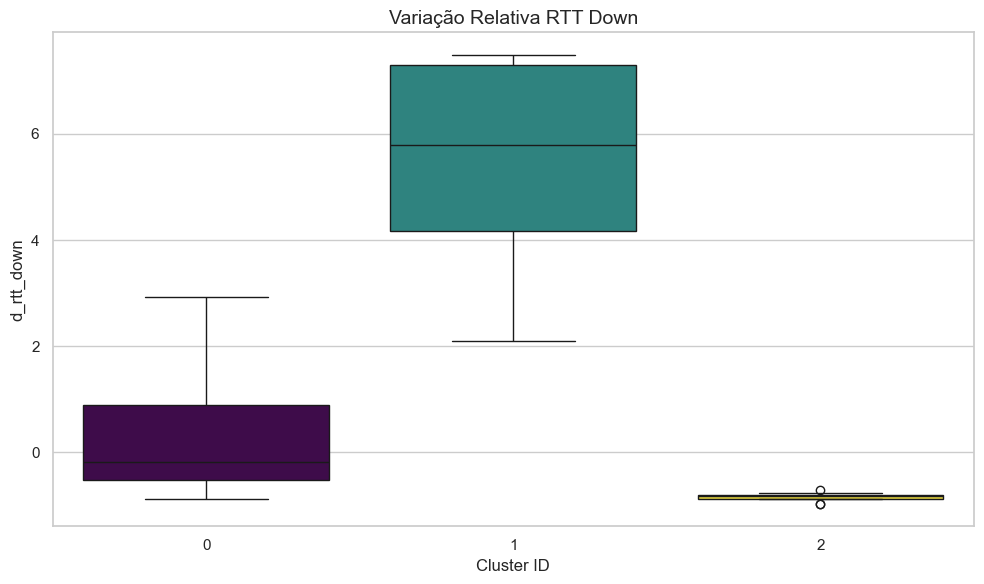

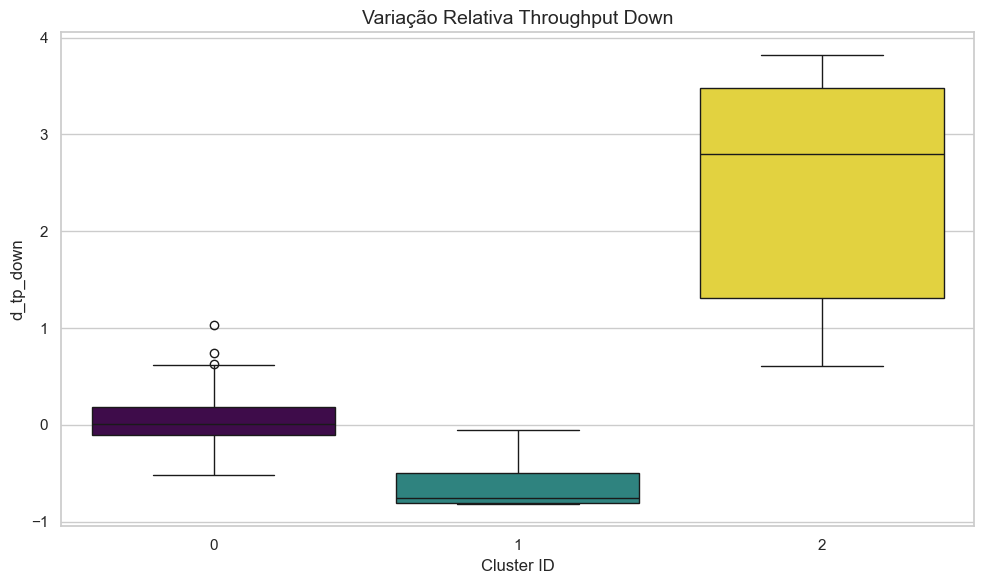

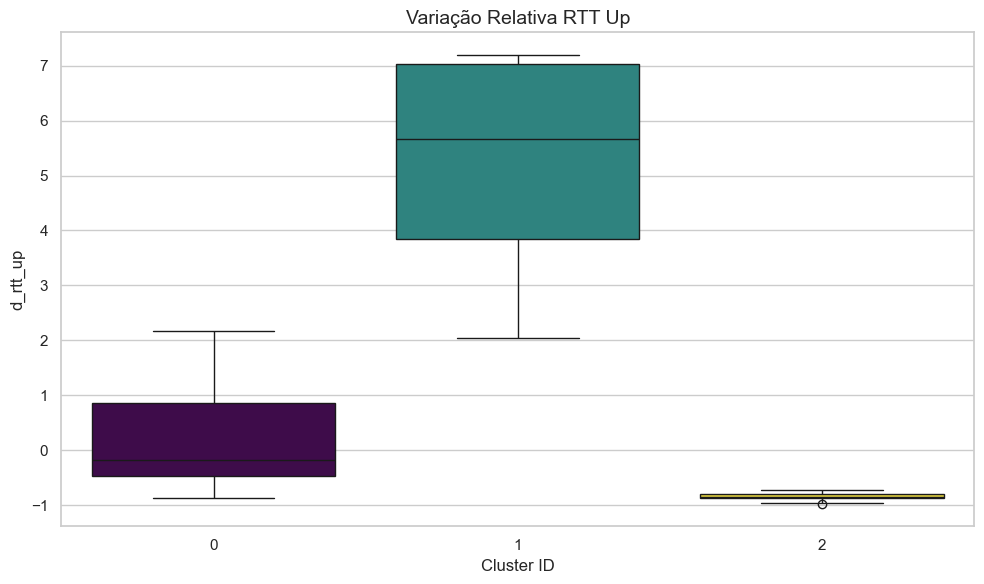

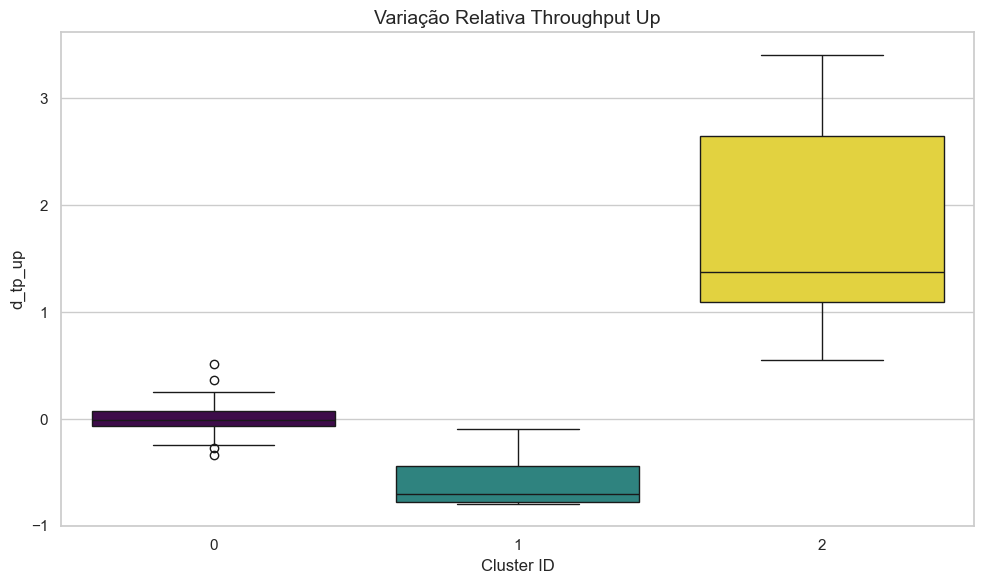

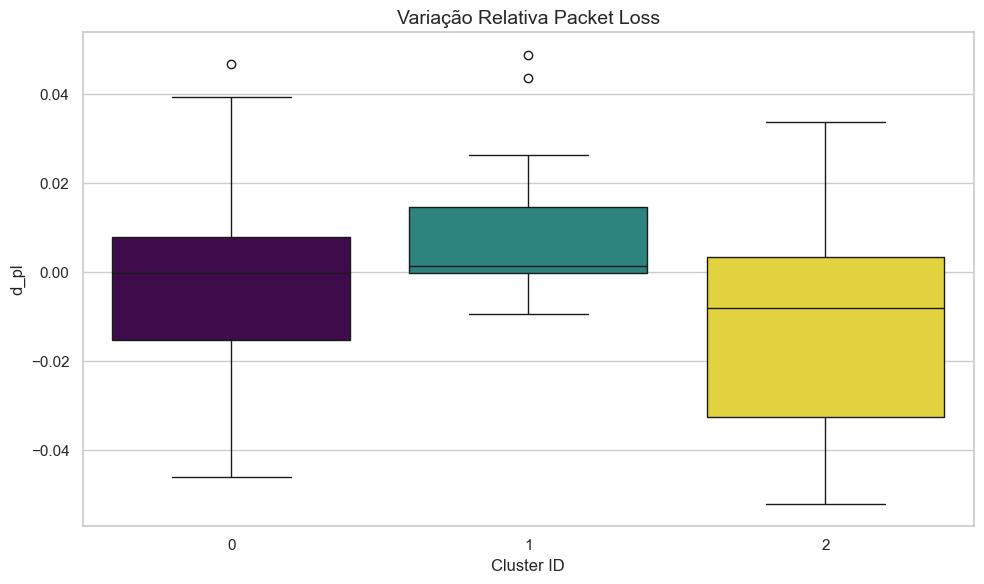

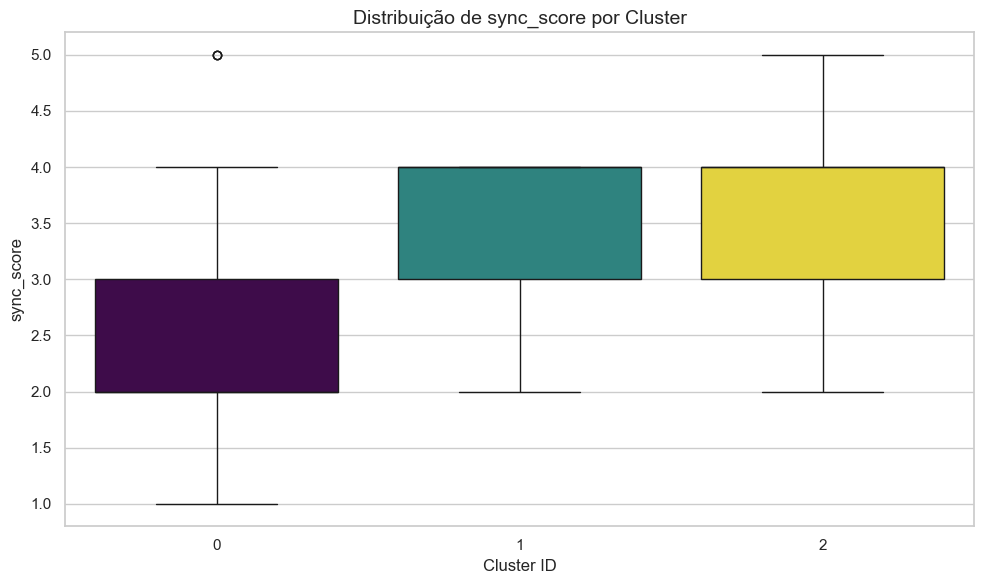

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

# MApeamento das métricas para títulos e cores
metric_info = {
    'd_rtt_down': (f'Variação Relativa RTT Down', 'teal'),
    'd_tp_down': ('Variação Relativa Throughput Down', 'darkred'),
    'd_pl': ('Variação Relativa Packet Loss', 'indigo'),
    'd_rtt_up': (f'Variação Relativa RTT Up', 'darkcyan'),
    'd_tp_up': ('Variação Relativa Throughput Up', 'firebrick')
}

# Iterar sobre cada métrica para criar uma figura individual
for col in feature_cols:
    plt.figure(figsize=(10, 6))
    
    # Criar o boxplot: X é o cluster, Y é a métrica atual
    sns.boxplot(x='cluster', y=col, data=df_cluster, palette='viridis', hue='cluster', legend=False)
    
    # Adicionar pontos (stripplot) para ver a distribuição real dos dados sobre o boxplot
    # sns.stripplot(x='cluster', y=col, data=df_filtrado, color='black', alpha=0.3, jitter=True)
    
    title, color = metric_info.get(col, (f'Distribuição de {col} por Cluster', 'blue'))
    plt.title(title, fontsize=14)
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel(col, fontsize=12)
    
    plt.tight_layout()
    plt.show()